<a href="https://colab.research.google.com/github/Shafnpt/HE-Fault-detection-and-control-system/blob/main/fault_separate_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
normal = pd.read_csv("/content/drive/MyDrive/HX_Normal.csv")
fouling = pd.read_csv("/content/drive/MyDrive/HX_Fouling.csv")
leakage = pd.read_csv("/content/drive/MyDrive/HX_Leakage.csv")
blockage = pd.read_csv("/content/drive/MyDrive/HX_Blockage.csv")

In [ ]:
print(normal.columns)

Index(['Time_hr', 'Shell_In_Temp_C', 'Shell_Out_Temp_C', 'Tube_In_Temp_C',
       'Tube_Out_Temp_C', 'Shell_Flow_kgph', 'Tube_Flow_kgph',
       'Heat_Duty_kcalph', 'Overall_U', 'DP_Shell_kgfpcm2', 'DP_Tube_kgfpcm2'],
      dtype='object')


In [ ]:
import numpy as np

def compute_features(df):

    df = df.copy()
    df.columns = df.columns.str.strip()

    # Find pressure drop columns automatically
    shell_dp = [c for c in df.columns if "Shell" in c and "DP" in c][0]
    tube_dp  = [c for c in df.columns if "Tube" in c and "DP" in c][0]

    # Pressure Drop
    df["Pressure_Drop"] = df[shell_dp] + df[tube_dp]

    # Temperature differences
    deltaT1 = df["Shell_In_Temp_C"] - df["Tube_Out_Temp_C"]
    deltaT2 = df["Shell_Out_Temp_C"] - df["Tube_In_Temp_C"]

    # Avoid log errors and handle LMTD edge cases
    epsilon = 1e-6 # Small value to prevent division by zero or log of zero/negative

    # Calculate LMTD. Handle cases where deltaT1 or deltaT2 are equal or problematic.
    # Using absolute values for the log argument to avoid RuntimeWarning, though physically
    # deltaT1 and deltaT2 should be positive for a standard LMTD calculation.
    log_arg = np.abs((deltaT1 + epsilon) / (deltaT2 + epsilon))

    # If deltaT1 is close to deltaT2, LMTD equals deltaT1 (or deltaT2)
    df["LMTD"] = np.where(
        np.isclose(deltaT1, deltaT2),
        deltaT1, # If temp differences are equal, LMTD is that difference
        (deltaT1 - deltaT2) / np.log(log_arg)
    )
    # Ensure LMTD is positive, as it's a physical quantity
    df["LMTD"] = df["LMTD"].apply(lambda x: max(x, epsilon))

    # Heat transfer area (set your HX area)
    AREA = 100

    df["U_real"] = df["Heat_Duty_kcalph"] / (AREA * df["LMTD"])

    df["Thermal_Resistance"] = 1 / df["U_real"]

    df["Temp_Efficiency"] = (
        (df["Shell_In_Temp_C"] - df["Shell_Out_Temp_C"]) /
        (df["Shell_In_Temp_C"] - df["Tube_In_Temp_C"])
    )

    df["Flow_Ratio"] = df["Shell_Flow_kgph"] / df["Tube_Flow_kgph"]

    df["Health_Index"] = df["U_real"] / df["Overall_U"]

    df["dP_dt"] = df["Pressure_Drop"].diff().fillna(0)

    # Remove invalid values
    df = df.replace([np.inf, -np.inf], np.nan)
    # Update fillna usage to avoid FutureWarning
    df = df.bfill()

    return df

In [ ]:
normal = compute_features(normal)
fouling = compute_features(fouling)
leakage = compute_features(leakage)
blockage = compute_features(blockage)

In [ ]:
features = [
'Pressure_Drop',
'U_real',
'Thermal_Resistance',
'Temp_Efficiency',
'Health_Index',
'Flow_Ratio',
'dP_dt'
]

In [ ]:
class HybridModel(nn.Module):

    def __init__(self,input_dim):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,2)
        )

    def forward(self,x):
        return self.net(x)

In [ ]:
def train_model(X_train,X_test,y_train,y_test):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_train = torch.tensor(X_train,dtype=torch.float32).to(device)
    X_test = torch.tensor(X_test,dtype=torch.float32).to(device)

    y_train = torch.tensor(y_train).long().to(device)
    y_test = torch.tensor(y_test).long().to(device)

    model = HybridModel(X_train.shape[1]).to(device)

    optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(30):

        optimizer.zero_grad()

        pred = model(X_train)

        loss = loss_fn(pred,y_train)

        loss.backward()
        optimizer.step()

        if epoch%5==0:
            print("Epoch",epoch,"Loss",loss.item())

    with torch.no_grad():

        preds = model(X_test)
        preds = torch.argmax(preds,1).cpu().numpy()

    return preds,y_test.cpu().numpy()

In [ ]:
def validate_fault(normal_df,fault_df,fault_name):

    print("\n============================")
    print("Validating:",fault_name)
    print("============================")

    X_train,X_test,y_train,y_test = create_dataset(normal_df,fault_df)

    preds,y_test = train_model(X_train,X_test,y_train,y_test)

    print(classification_report(y_test,preds))

    cm = confusion_matrix(y_test,preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,annot=True,fmt="d")
    plt.title(f"{fault_name} Confusion Matrix")
    plt.show()


Validating: Fouling
Epoch 0 Loss 0.674471914768219
Epoch 5 Loss 0.6097346544265747
Epoch 10 Loss 0.5494469404220581
Epoch 15 Loss 0.4874474108219147
Epoch 20 Loss 0.4219958186149597
Epoch 25 Loss 0.3571864068508148
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42048
           1       1.00      1.00      1.00     21024

    accuracy                           1.00     63072
   macro avg       1.00      1.00      1.00     63072
weighted avg       1.00      1.00      1.00     63072



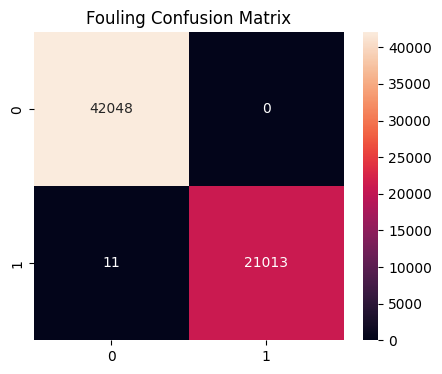


Validating: Leakage
Epoch 0 Loss 0.670538067817688
Epoch 5 Loss 0.6263916492462158
Epoch 10 Loss 0.5833600759506226
Epoch 15 Loss 0.5376437902450562
Epoch 20 Loss 0.4857460856437683
Epoch 25 Loss 0.42685607075691223
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42048
           1       1.00      1.00      1.00     21024

    accuracy                           1.00     63072
   macro avg       1.00      1.00      1.00     63072
weighted avg       1.00      1.00      1.00     63072



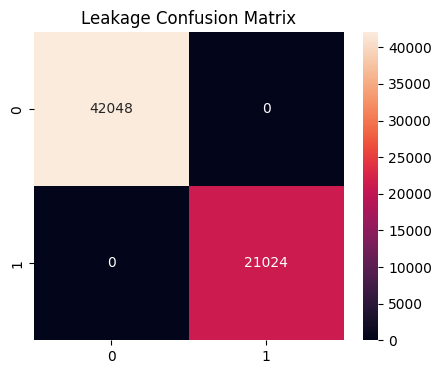


Validating: Blockage
Epoch 0 Loss 0.6967036724090576
Epoch 5 Loss 0.6515354514122009
Epoch 10 Loss 0.6134988069534302
Epoch 15 Loss 0.5783948302268982
Epoch 20 Loss 0.5465971827507019
Epoch 25 Loss 0.5185933709144592
              precision    recall  f1-score   support

           0       0.77      1.00      0.87     42048
           1       1.00      0.39      0.56     21024

    accuracy                           0.80     63072
   macro avg       0.88      0.70      0.71     63072
weighted avg       0.84      0.80      0.77     63072



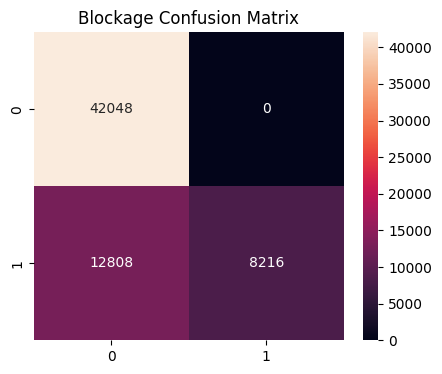

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def create_dataset(normal_df, fault_df):
    # Compute derived features for both normal and fault dataframes using the current compute_features
    normal_data_with_features = compute_features(normal_df)
    fault_data_with_features = compute_features(fault_df)

    # Select only the specified features from the dataframes with computed features
    # 'features' list is defined in cell RyQXhqLUvxMf
    normal_data = normal_data_with_features[features]
    fault_data = fault_data_with_features[features]

    # Create labels
    normal_labels = np.zeros(len(normal_data))
    fault_labels = np.ones(len(fault_data))

    # Combine data and labels
    X = pd.concat([normal_data, fault_data], ignore_index=True)
    y = np.concatenate([normal_labels, fault_labels])

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

    return X_train, X_test, y_train, y_test

validate_fault(normal,fouling,"Fouling")

validate_fault(normal,leakage,"Leakage")

validate_fault(normal,blockage,"Blockage")

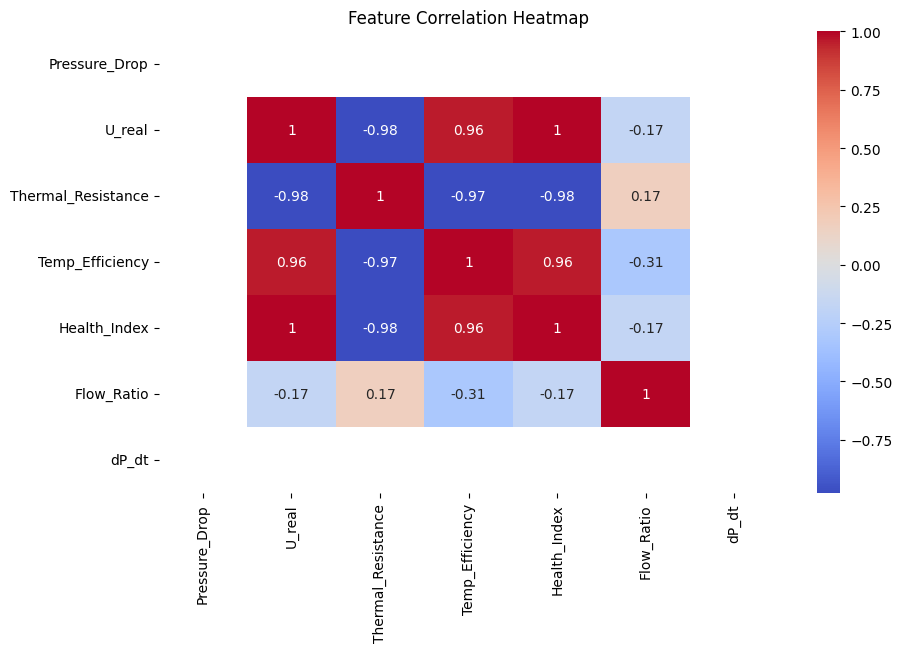

In [ ]:
plt.figure(figsize=(10,6))

# Add derived features to the normal DataFrame before computing correlations
normal_with_features = compute_features(normal)
sns.heatmap(normal_with_features[features].corr(),annot=True,cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()